# Data, Race, and Policing

<!--- Data frames, Series, Boolean indexing, for loops, missing values,
simulations -->

Work through the notebook from beginning to the end.

Execute any cells that you are given, and fill in the ones that you need to
fill in.

You will see the marks for each question in the comments.

To start, execute the cell below, that gets the standard libraries and settings
for plots.

As usual, it also loads the OKpy testing library.  Further down in the
notebook, there are OKpy cells for you to run for many of the questions.  **If
the OKpy cells pass, it doesn't mean you have the marks for that question, it
only means you are on the right track**.

In [305]:
# Don't change this cell; just run it.

# Load the Numpy array module with variable name 'np'.
import numpy as np
# Load Pandas data table module with variable name 'pd'.
import pandas as pd
# Turn on a setting to use Pandas more safely.
# We will discuss this setting later.
pd.set_option('mode.chained_assignment', 'raise')
# Load "pyplot" submodule of Matplotlib plotting module
# with variable name "plt".
import matplotlib.pyplot as plt
# Make plots look a little more fancy.
plt.style.use('fivethirtyeight')
# Tell plotting package to display plots inside the notebook.
%matplotlib inline

# Load the OKpy testing library
from client.api.notebook import Notebook
ok = Notebook('race_policing.ok')

Assignment: demographics
OK, version v1.18.1



## Ethnicity in the West Midlands

We wonder whether the West Midlands police force is, for whatever reason, more
likely to stop and search not-white people than white people.   To work out
whether this is true, we first have to consider the proportions of white and
not-white people in the population.  If 80% of the people that the police stop
are black, that sounds like bias, unless 80% of the population are black, in
which case they may be treating everyone equally.

We need to compare the percentages of the different ethnicities in the West Midlands with the ethnicities of those stopped and searched.

Our first task is therefore to find the proportions of each race / ethnicity in the West midlands.

### Ethnicity data

The government publishes
[statistics](https://www.ethnicity-facts-figures.service.gov.uk/british-population/national-and-regional-populations/regional-ethnic-diversity/latest)
on the percentages of each ethnic group in the regions of England and Wales.

Here you are reading the [source data for Areas of England and Wales by
ethnicity](https://www.ethnicity-facts-figures.service.gov.uk/british-population/national-and-regional-populations/regional-ethnic-diversity/latest/downloads/areas-of-england-and-wales-by-ethnicity.csv).

I downloaded the file
[areas-of-england-and-wales-by-ethnicity](./areas-of-england-and-wales-by-ethnicity.csv)
from the link above.

Execute the following cell to load the data as a Pandas data frame, and then
display the first five rows.

In [306]:
# Load the data from a file in the same directory as the notebook.
regions_by_eth = pd.read_csv('areas-of-england-and-wales-by-ethnicity.csv')
# Show the first five rows.
regions_by_eth.head()

,Standard Ethnicity,Region,%
0,Asian,East,4.8
1,Asian,East Midlands,6.5
2,Asian,London,18.5
3,Asian,North East,2.9
4,Asian,North West,6.2


Now your turn.  First get the "Region" column of the data frame into its own
variable.  A bit further down, you are going to use this to select the "West
Midlands" rows from this data frame.

In [307]:
#- Put the "Region" column of the data frame into a new variable "regions".
#- 2 marks / 100 (total 2 so far)
regions = regions_by_eth["Region"]
# Show the result
regions

0                         East
1                East Midlands
2                       London
3                   North East
4                   North West
5                   South East
6                   South West
7                        Wales
8                West Midlands
9     Yorkshire and The Humber
10                        East
11               East Midlands
12                      London
13                  North East
14                  North West
15                  South East
16                  South West
17                       Wales
18               West Midlands
19    Yorkshire and The Humber
20                        East
21               East Midlands
22                      London
23                  North East
24                  North West
25                  South East
26                  South West
27                       Wales
28               West Midlands
29    Yorkshire and The Humber
30                        East
31               East Midlands
32      

Here is an OKpy test, to see if you are on the right track. Remember - these
tests only check whether you are on the right track. If the test passes, it
does not mean you have full marks for the question.

In [308]:
# Check answer is on right track.
_ = ok.grade('q_1_regions')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



Make a variable `is_west_midlands` that is a Series with `True` in the
elements corresponding to the "West Midlands" elements in `regions` and
`False` otherwise.

In [309]:
#- "is_west_midlands" should have True for elements corresponding to West
#- Midlands, False otherwise.
#- 3 marks / 100 (total 5 so far)
is_west_midlands = regions == "West Midlands"
# Show the first five values
is_west_midlands.head()

0    False
1    False
2    False
3    False
4    False
Name: Region, dtype: bool

In [310]:
# Check answer is on right track.
_ = ok.grade('q_2_is_wm')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



Make a new data frame `west_midlands_by_eth` that only contains the rows from
`regions_by_eth` that correspond to the West Midlands.

In [311]:
#- 5 marks / 100 (total 10 so far)
west_midlands_by_eth = regions_by_eth[is_west_midlands]
# Show the first five rows.
west_midlands_by_eth.head()

,Standard Ethnicity,Region,%
8,Asian,West Midlands,10.8
18,Black,West Midlands,3.3
28,Mixed,West Midlands,2.4
38,White British,West Midlands,79.2
48,White other,West Midlands,3.6


In [312]:
# Check answer is on right track.
_ = ok.grade('q_3_wm_by_eth')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



`west_midlands_by_eth` has percentages of the population, for each ethnicity.
For example, you should see above that the "White British" ethnicity is the
ethnicity claimed by a large proportion of the population of West Midlands.

Now you are building up to making a horizontal bar plot of the different
ethnicities in the West Midlands.  Start by sorting the data frame, with the
most common ethnicity first.

Remember, the name of the percent column is `"%"` (a string with a single
character - the percent sign).

In [313]:
#- Make a new data frame "west_midlands_sorted" by sorting
#- "west_midlands_by_eth" by the "%" column.  Largest values should come first.
#- 5 marks / 100 (total 15 so far)
west_midlands_sorted = west_midlands_by_eth.sort_values("%", ascending=False)
# Show first five rows of the sorted data frame.
west_midlands_sorted.head()

,Standard Ethnicity,Region,%
38,White British,West Midlands,79.2
8,Asian,West Midlands,10.8
48,White other,West Midlands,3.6
18,Black,West Midlands,3.3
28,Mixed,West Midlands,2.4


In [314]:
# Check answer is on right track.
_ = ok.grade('q_4_wm_sorted')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 4
    Failed: 0
[ooooooooook] 100.0% passed



Now display a horizontal bar plot of the ethnicities.  When you have done this
correctly, you should see the ethnicities listed on the left of the vertical
axis, with the *least* common ethnicity first.  The horizontal axis corresponds
to percent.  You should see coloured bars going from left to right, with the
longest bar at the bottom, corresponding to the percentage of "White British".

*Hint*: Use tab completion to investigate the methods contained in
`west_midlands_sorted.plot` for a plausible plot type to try.

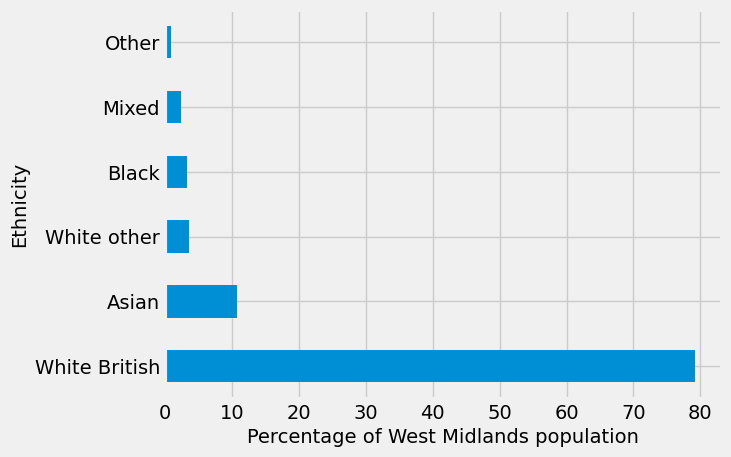

In [386]:
#- 5 marks / 100 (total 20 so far)
west_midlands_sorted.plot.barh(x="Standard Ethnicity", y="%", legend=False)
plt.xlabel("Percentage of West Midlands population")
plt.ylabel("Ethnicity");

This is a little more difficult.   In the next section of this assignment,
you are going to use the value for the percentage of the West Midlands
population that is "White British".  It is useful to fetch that number and
store it in a variable.

Try doing that in the next cell.  Run the OKpy test to see if you've got the
right answer.  Please don't type in the answer, but write code to fetch the
right number from a suitable data frame.

In [316]:
#- Put the West Midlands percentage of "White British" into a new variable
#- "white_british_pct".  You will probably need more than one line of code.
#- 5 marks / 100 (total 25 so far)
white_british_row =  west_midlands_by_eth[
    west_midlands_by_eth["Standard Ethnicity"] == "White British"
] 
white_british_pct = white_british_row["%"].iloc[0]
# Show the result converted to a simple floating point value.
float(white_british_pct)

79.2

In [317]:
_ = ok.grade('q_6_wb_pct')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 2
    Failed: 0
[ooooooooook] 100.0% passed



## Stop and search

Now we analyze the stop and search data.  We will compare the stop and search
data to the ethnicity proportions we found above.

The UK police publish various statistics about their work at
<https://data.police.uk/data>.

I went to this site, selected "September 2020" as the start and end of the
"Date range", selected "West Midlands Police" in the "Forces" panel,
unselected "include crime data" and selected "include stop and search data".
Then I clicked "Generate" and downloaded, unpacked the generated zip file. This
gave me the file in this directory:
[2020-09-west-midlands-stop-and-search.csv](./2020-09-west-midlands-stop-and-search.csv).

The rows in this data file are records of all the stop-search incidents by
members of the West Midlands police force during September 2020.

First load this file as a data frame.

In [318]:
#- Load the file "2020-09-west-midlands-stop-and-search.csv"
#- as a data frame.
#- Put the new data frame into a variable "stop_search".
#- 2 marks / 100 (total 27 so far)
stop_search = pd.read_csv("2020-09-west-midlands-stop-and-search.csv")
# Show the first 5 rows.
stop_search.head()

,Type,Date,Part of a policing operation,Policing operation,Latitude,Longitude,Gender,Age range,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome,Outcome linked to object of search,Removal of more than just outer clothing
0,Person search,2020-09-01T00:24:00+00:00,NaN,NaN,52.587184,-2.011440,NaN,over 34,Asian/Asian British - Pakistani,Asian,Misuse of Drugs Act 1971 (section 23),Controlled drugs,Penalty Notice for Disorder,NaN,False
1,Person search,2020-09-01T00:30:00+00:00,NaN,NaN,52.575702,-1.838244,NaN,18-24,White - English/Welsh/Scottish/Northern Irish/...,NaN,Police and Criminal Evidence Act 1984 (section 1),Stolen goods,Arrest,NaN,False
2,Person search,2020-09-01T00:57:00+00:00,NaN,NaN,52.587184,-2.011440,NaN,NaN,Asian/Asian British - Any other Asian background,NaN,Police and Criminal Evidence Act 1984 (section 1),Stolen goods,A no further action disposal,NaN,False
3,Person search,2020-09-01T01:21:00+00:00,NaN,NaN,52.473434,-1.895018,NaN,NaN,Mixed/Multiple ethnic groups - Any other Mixed...,NaN,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False
4,Person search,2020-09-01T01:22:00+00:00,NaN,NaN,52.473434,-1.895018,NaN,18-24,Mixed/Multiple ethnic groups - White and Black...,NaN,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False


In [319]:
_ = ok.grade('q_7_stop_search')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



We are particularly interested in two columns - `Self-defined ethnicity` and
`Outcome`.

We return to the question as to whether the West Midlands police force is, for
whatever reason, more likely to stop not-white people than white people.  This
boils down the question whether the proportion of not-white people stopped and
searched is very different from the proportion of not-white people in the
population. We need to compare the proportions of the different ethnicities in
the West Midlands with the ethnicities of those stopped and searched.

We are about to see that is a problem, because the categories in this table
are not quite the same as the categories in the demographic data you analyzed
in the early parts of this notebook.

In [320]:
#- Make a new variable "ethnicity" that has the values from
#- the "Self-defined ethnicity" column of "stop_search".
#- 2 marks / 100 (total 29 so far)
ethnicity = stop_search["Self-defined ethnicity"]
# Show the first five values
ethnicity.head()

0                      Asian/Asian British - Pakistani
1    White - English/Welsh/Scottish/Northern Irish/...
2     Asian/Asian British - Any other Asian background
3    Mixed/Multiple ethnic groups - Any other Mixed...
4    Mixed/Multiple ethnic groups - White and Black...
Name: Self-defined ethnicity, dtype: object

In [321]:
# Check you are on the right track.
_ = ok.grade('q_8_ethnicity')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



Display the `type` of the `ethnicity` variable.

In [322]:
# Run this cell.
type(ethnicity)

pandas.core.series.Series

You should find that `ethnicity` is a Pandas `Series` type.  That is the type
Pandas uses to contain columns of data.

This series has the recorded ethnicities for each person who suffered a stop
and search.  We would like to see all the different ethnicities, with a count
of how many times they appear.

Use the `value_counts` method of `ethnicity` to get the unique values in
`ethnicity`, along with the number of times these values occur.  Put the
results into the variable `eth_counts`.


In [323]:
#- 3 marks / 100 (total 32 so far)
eth_counts = ethnicity.value_counts()
# Show the result
eth_counts

Self-defined ethnicity
White - English/Welsh/Scottish/Northern Irish/British                                   657
Asian/Asian British - Pakistani                                                         314
Black/African/Caribbean/Black British - Caribbean                                       141
Black/African/Caribbean/Black British - African                                         138
Asian/Asian British - Indian                                                            101
Other ethnic group - Not stated                                                          97
White - Any other White background                                                       92
Mixed/Multiple ethnic groups - White and Black Caribbean                                 85
Asian/Asian British - Any other Asian background                                         79
Black/African/Caribbean/Black British - Any other Black/African/Caribbean background     55
Asian/Asian British - Bangladeshi                        

In [324]:
# Check you are on the right track.
_ = ok.grade('q_9_eth_counts')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



Compare these ethnicity labels to the ones in the previous section.  They do
not correspond exactly.  We need to recode the ethnicities recorded in this
column to match those in the previous section.

To do this, we can use a recoding function.  Doing this needs a little more
machinery that you have covered so far, so the next few cells do the recoding
for you.

First I write my own function, that takes a single argument `value`.  `value`
will be a single ethnicity value from the `ethnicity` series above.  It
returns my best guess at the corresponding ethnicity from the demographics
data in the other table.  For example, I guess that both of the  "White -
English ..." and "White - Irish" ethnicities in the series correspond to the
"White British" category in the demographics table from the other table.

Do not worry about the details of this function, just run the cell below to
define it.

In [325]:
# A function to recode ethnicity.
# Run this cell to define the function.
def recode_eth(value):
    """ Recode ethnicity values to match standard

    Accept ethnicity string as used in "Self-defined ethnicity".
    Return matching ethnicity used by the government statistics
    on ethnicity.
    """
    if pd.isna(value):  # Missing value
        return np.nan
    if value.startswith('Asian'):
        return 'Asian'
    if value.startswith('Mixed'):
        return 'Mixed'
    if value.startswith('Black'):
        return 'Black'
    if value.startswith('White - English'):
        return 'White British'
    if value.startswith('White - Irish'):
        return 'White British'
    if value.startswith('White - Any other'):
        return 'White other'
    if value.startswith('Other ethnic group'):
        return 'Other'
    # If we didn't already return something, stop here
    # with an error.
    raise ValueError('Did not expect ethnicity ' + value)

The next couple of cells are just to show how the encoding function works. I
call the function on a couple of the values that appear in the `ethnicity`
series from the stop and search data.

In [326]:
# Run this cell.
# Show example of the recoding function in action
recode_eth('Asian/Asian British - Indian')

'Asian'

In [327]:
# Run this cell.
# Another example
recode_eth('White - Irish')

'White British'

Last in this recoding sequence of cells, run this cell to "apply" the
`recode_eth` function above to all the values in the `ethnicity` series in
turn.  This returns a new series of the same length as `ethnicity`, but with
the recoded values.

In [328]:
# Run this cell to use the "apply" method of "ethnicity",
# and the "recode_eth" function above, to make a new variable
# "recoded_eth".  This has the ethnicity values recoded to the
# form used in the UK government demographics.
recoded_eth = ethnicity.apply(recode_eth)
# Display the first give values of "recoded_eth"
recoded_eth.head()

0            Asian
1    White British
2            Asian
3            Mixed
4            Mixed
Name: Self-defined ethnicity, dtype: object

If you have run the cells above, you now have a new series called
`recoded_eth`, with the recoded ethnicity values for each stop and search
incident.

Just to check, calculate the unique values in this new series, and the number
of times each value appears.

In [329]:
#- Make a new variable "recoded_eth_counts" that has the unique values of
#- "recoded_eth", and their counts.
#- 2 marks / 100 (total 34 so far)
recoded_eth_counts = recoded_eth.value_counts()
# Show the values of "recoded_eth_counts"
recoded_eth_counts

Self-defined ethnicity
White British    680
Asian            531
Black            334
Mixed            151
Other             97
White other       92
Name: count, dtype: int64

In [330]:
# Check you are on the right track.
_ = ok.grade('q_10_recoded_eth_counts')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



The counts in `recoded_eth_counts` are the total number of people from each
ethnicity that were stopped and searched by the West Midlands police.  We want
to compare these counts, by eye, using a horizontal bar graph.

If you get the graph right, you should see the recoded ethnicities listed to
the left of the vertical axis. The horizontal axis corresponds to the counts
for every ethnicity.  You should see the more common ethnicities (ethnicities
with higher counts) appear at the bottom.

Be careful - here you are about to use one of the `plot.` methods of the
`recoded_eth_counts` *series*.  In the earlier section, you may have used a
`plot.` method of a *data frame*.   These are not quite the same.  For example,
in a data frame, we have to tell the method which columns to use for the plot.
For the series, there is only one column, so the method will not need the same
information.  You can check what information the method needs by making a new
cell and running `recoded_eth_counts.plot.eg_method?` to show the help for your
method (replace `eg_method` by the name of the method you are using).

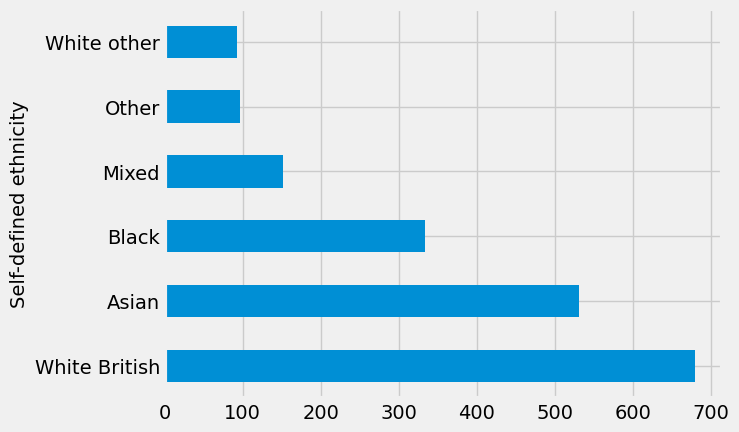

In [387]:
#- Use a "plot." method of "recoded_eth_counts" to show a
#- horizontal bar chart of the counts for each ethnicity.
#- The ethnicity should display on the vertical axis
#- and the count on the horizontal axis.
recoded_eth_counts.plot.barh()
plt.ylabel("Self-defined ethnicity");

Notice that some of values in `recode_eth` are missing.  We can tell, by comparing the output of the `.count` method to the number of values.  `.count` only counts valid values, so the difference between `.count` and the number of values is the number of missing values.

In [332]:
print('Number of valid values in "recoded_eth"', recoded_eth.count())
print('Number of values in "recoded_eth"', len(recoded_eth))

Number of valid values in "recoded_eth" 1885
Number of values in "recoded_eth" 2051


Values are missing for stop-search incidents where the officer did not record
the ethnicity of the suspect.

The missing values are going to be a problem for us later on, because we can
only analyze ethnicities for the stop and search incidents when we have a
recorded ethnicity.

In fact, we will later be interested in the "Outcome" of each stop-search incident.  Some of these values are also missing.

To deal with this, we first first make a new data frame, that only has our two
columns of interest.  Later, we will drop the rows from this data frame
corresponding to missing values in either the recoded ethnicity or the
"Outcome".

Use the cell below to make the new data frame.

In [333]:
# Run this cell.
# Make a new empty data frame
eth_outcome = pd.DataFrame()
# Insert the recoded_eth series.
# The .copy() is for safety.  More later in the course.
eth_outcome['recoded_eth'] = recoded_eth.copy()
# Insert a copy of the outcome series from the original data frame.
eth_outcome['Outcome'] = stop_search['Outcome'].copy()
# Show the first five rows.
eth_outcome.head()

,recoded_eth,Outcome
0,Asian,Penalty Notice for Disorder
1,White British,Arrest
2,Asian,A no further action disposal
3,Mixed,A no further action disposal
4,Mixed,A no further action disposal


Now we need to drop all rows where *either* the `recoded_eth` column *or* the
`Outcome` column has invalid values (values that not missing), giving a new
data frame `valid_eth_outcome` that has no rows with any missing values.

*Hint*: Investigate the `dropna` method of `eth_outcome`

In [334]:
#- Make a new variable "valid_eth_outcome" containing a data frame restricted
#- to rows with no missing values.
#- 3 marks / 100 (total 40 so far)
valid_eth_outcome = eth_outcome.dropna()
# Show the first 5 rows
valid_eth_outcome.head()

,recoded_eth,Outcome
0,Asian,Penalty Notice for Disorder
1,White British,Arrest
2,Asian,A no further action disposal
3,Mixed,A no further action disposal
4,Mixed,A no further action disposal


In [335]:
# Check you are on the right track.
_ = ok.grade('q_12_valid_eth')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 4
    Failed: 0
[ooooooooook] 100.0% passed



## Testing for racial bias in stop and search

Now we want to work out whether the number of "White - British" people who
were stopped and searched is compatible with the following model:

**Ideal / Null model**: *Any person in the West Midlands has an equal chance
of being stopped and searched, regardless of their ethnicity.*

As we saw above, 79.2 percent of the West Midlands population is "White British".

Therefore, our ideal model says that any given person who is stopped and
searched has a 79.2 percent chance of being "White British".

Is that ideal model compatible with the data that we actually see?

In the next few cells, you do a simulation to find out.

First we get the number of remaining stop search incidents in our table, now
we have removed all rows with any missing values:

In [337]:
# Run this cell.
# The number of rows remaining in our table.
n_valid_eth = len(valid_eth_outcome)
n_valid_eth

1716

Next, we calculate the *proportion* of these remaining stop-search incidents
that have "White British" values for the `recoded_eth` column of
`valid_eth_outcome` data frame.

*Hint*: consider a Boolean series as the basis of your count.

In [338]:
#- 3 marks / 100 (total 43 so far)
#- Calculate the proportion of 'White British' values in "valid_eth_outcome".
n_wb = np.count_nonzero(valid_eth_outcome["recoded_eth"] == "White British")
prop_wb = n_wb / len(valid_eth_outcome)
# Show the result.
prop_wb

0.36013986013986016

In [339]:
# Check you are on the right track.
_ = ok.grade('q_12a_prop_wb')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



Is this `prop_wb` proportion compatible with police doing stop-search at
random, without regard to ethnicity?   Is it compatible with our ideal model?

As for the other simulations we have done, we start with some random numbers.

We will use these to simulate whether the person stopped is "White British" or
not.

One trial is one month's worth of stop-search data - so each trial has
`n_valid_eth` simulated stop search incidents.  The statistic we are
interested in for each trial is the proportion of White British people stopped
and searched.

As usual, we begin with a cell to simulate one trial (one month of
stop-search).  Our interest is in the proportion of stop-search incidents that
are on White British suspects. Notice we us `np.random.uniform` to give us
`n_valid_eth` random numbers between 0 and 1, and we use those to get a 0.792
chance of a True value.  We're expecting some proportion not very far from
0.792.


In [340]:
# Simulation of proportion from a single month of stop-search incidents.
randoms = np.random.uniform(0, 1, size=n_valid_eth)
wb_incidents = randoms < 0.792
simulated_prop = np.count_nonzero(wb_incidents) / n_valid_eth
simulated_prop

0.7814685314685315

Now for your simulation.  Use this simulation for one month to do simulations
for 10000 months.  Store the results of the `simulated_prop` proportion for
each of these 10000 months in an array called `sim_wb_proportions`.

In [341]:
#- 5 marks / 100 (total 48 so far)
#- Run 10000 trials.  Collect the proportions at each trial.
#- Store the proportions in an array sim_wb_proportions.
sim_wb_proportions = np.zeros(10000)

for i in range(10000):
    randoms = np.random.uniform(0, 1, size=n_valid_eth)
    sim_wb = randoms < 0.792
    sim_wb_proportions[i]= np.count_nonzero(sim_wb) / n_valid_eth

# Show the simulated proportions
sim_wb_proportions

array([0.80244755, 0.78379953, 0.80128205, ..., 0.79312354, 0.79195804,
       0.8006993 ])

In [342]:
# Check you are on the right track.
_ = ok.grade('q_13_sim_wb_proportions')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 5
    Failed: 0
[ooooooooook] 100.0% passed



You now have an array with 10000 values, where each value is the *proportion*
of White British people in one simulation.

Plot a histogram of this array to show the spread of these proportions. Our
simulation model means that these proportions have come about by random
sampling, so this is the *sampling distribution of the proportion*.

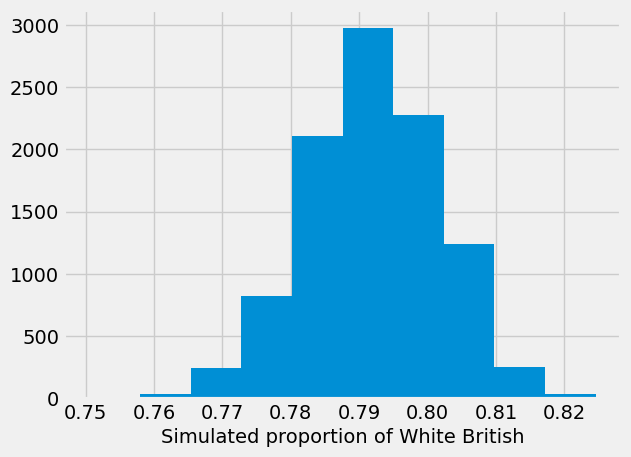

In [388]:
#- Show a histogram of the proportions in the "sim_wb_proportions" array.
#- 2 marks / 100 (total 50 so far)
plt.hist(sim_wb_proportions)
plt.xlabel("Simulated proportion of White British");

Looking at this histogram, how likely is it, that the proportion that we
observe for the number of "White British" people stopped, could have come
about under the assumptions of our ideal model?

Assign either 1, 2, 3, 4, or 5 to the name `likely_no_bias` below.

1. Reasonably likely.
2. Fairly unlikely, but not unlikely enough to be surprising.
3. Unlikely, but we still cannot be confident the model is incorrect.
4. Highly unlikely, we have strong evidence the model is incorrect.
5. The observed result is impossible given the model assuming no difference.

In [344]:
#- 5 marks / 100 (total 55 so far)
likely_no_bias = 4

The next cell checks that your answer above is in the correct format. This
test *does not* check that you answered correctly; only that you assigned a
number successfully in the multiple-choice answer cell.

In [345]:
_ = ok.grade('q_14_1_no_bias')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



## Are arrests biased?

We are suspicious that the police may be more likely to stop a not-white
person, but, if they do stop them, are they more likely to arrest them?  Do
white people get off with a caution or no action more often than a not-white
person?

The `valid_eth_outcome` data frame has a column `Outcome`, that comes from the
`stop_search` data frame. It gives information on what happened after the stop
and search.

Make a new variable `outcomes` that has the values from the "Outcome" column
of `valid_eth_outcome`.

In [346]:
#- 2 marks / 100 (total 57 so far)
outcomes = valid_eth_outcome['Outcome']
# Show the first five values in outcomes
outcomes.head()

0     Penalty Notice for Disorder
1                          Arrest
2    A no further action disposal
3    A no further action disposal
4    A no further action disposal
Name: Outcome, dtype: object

In [347]:
# Check you are on the right track.
_ = ok.grade('q_15_outcomes')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 4
    Failed: 0
[ooooooooook] 100.0% passed



As before, it is useful to have a look at the unique values in `outcomes`, and
the counts of the number of times each value appears.

Calculate and store the unique values and counts for outcomes in the variable
`outcomes_counts`.

In [348]:
#- 2 marks / 100 (total 59 so far)
outcomes_counts = outcomes.value_counts()
# Show the result.
outcomes_counts

Outcome
A no further action disposal       1341
Arrest                              275
Khat or Cannabis warning             66
Penalty Notice for Disorder          12
Summons / charged by post             9
Community resolution                  8
Caution (simple or conditional)       5
Name: count, dtype: int64

In [349]:
# Check you are on the right track.
_ = ok.grade('q_16_outcomes_counts')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



We want to find which of these outcomes correspond to a White British person,
and which do not.  To do this, we need to use the `recoded_eth` column in the
`valid_eth_outcome` data frame to select values from the `Outcome` column.
Put the result in `white_outcomes`.

*Hint*: In getting your answer, you may consider using a Boolean series that
has True in positions corresponding to "White British" in `recoded_eth` column
of `valid_eth_outcome` and False otherwise.

In [350]:
#- 6 marks / 100 (total 65 so far)
white = valid_eth_outcome["recoded_eth"] == "White British"
white_outcomes = valid_eth_outcome.loc[white, "Outcome"]
# Show the first five values.
white_outcomes.head()

1                           Arrest
8     A no further action disposal
9     A no further action disposal
10                          Arrest
14                          Arrest
Name: Outcome, dtype: object

In [351]:
# Check you are on the right track.
_ = ok.grade('q_19_white_outcomes')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



We have previously seen the breakdown of unique outcomes, and counts of these
outcomes, for the whole `outcomes` series.  Now do the same to show the unique
values, and their counts, for the `white_outcomes` series.

In [352]:
#- Calculate the unique values and counts of the different outcomes, for
#- White British people who were stopped and searched.
#- 2 marks / 100 (total 67 so far)
white_outcomes_counts = white_outcomes.value_counts()

white_outcomes_counts

Outcome
A no further action disposal       487
Arrest                              87
Khat or Cannabis warning            26
Community resolution                 6
Penalty Notice for Disorder          6
Summons / charged by post            4
Caution (simple or conditional)      2
Name: count, dtype: int64

In [353]:
# Check you are on the right track.
_ = ok.grade('q_20_white_outcomes_counts')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



Calculate the proportion of stopped White British people that were arrested.
Don't write in the numbers you've found above, use code to calculate the
number of White British people who were arrested, and the total number of
White British people.

*Hint* - one option is to calculate a new Boolean Series on the way to your
solution.

In [354]:
#- 5 marks / 100 (total 72 so far)
white_arrested_p = np.count_nonzero(white_outcomes == "Arrest") / len(white_outcomes)
white_arrested_p

0.1407766990291262

In [355]:
# Check you are on the right track.
_ = ok.grade('q_20_1_white_arrested_p')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



We know the frequencies of different outcomes for White British people; we
would like to calculate the same information for not-white people.

Select the `outcomes` that correspond to people with some value other than
"White British" as their ethnicity.  Put the result into the variable
`not_white_outcomes`.

In [356]:
#- 5 marks / 100 (total 77 so far)
not_white = valid_eth_outcome["recoded_eth"] != "White British"
not_white_outcomes = valid_eth_outcome.loc[not_white, "Outcome"]
not_white_outcomes.head()

0     Penalty Notice for Disorder
2    A no further action disposal
3    A no further action disposal
4    A no further action disposal
5    A no further action disposal
Name: Outcome, dtype: object

In [357]:
# Check you are on the right track.
_ = ok.grade('q_22_not_white_outcomes')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



Calculate and show the corresponding counts for not-White British outcomes.

In [358]:
#- 2 marks / 100 (total 79 so far)
not_white_outcomes_counts = not_white_outcomes.value_counts()
not_white_outcomes_counts

Outcome
A no further action disposal       854
Arrest                             188
Khat or Cannabis warning            40
Penalty Notice for Disorder          6
Summons / charged by post            5
Caution (simple or conditional)      3
Community resolution                 2
Name: count, dtype: int64

In [359]:
# Check you are on the right track.
_ = ok.grade('q_23_not_white_outcomes_counts')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



Calculate the proportion of not-white people who were arrested after they were
stopped.

In [360]:
#- 3 marks / 100 (total 82 so far)
not_white_arrested_p = np.count_nonzero(not_white_outcomes == "Arrest") / len(not_white_outcomes)
not_white_arrested_p

0.17122040072859745

In [361]:
# Check you are on the right track.
_ = ok.grade('q_23_1_not_white_arrested_p')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



Now we will try and work out whether there appears to be a difference between
the arrest / don't arrest decision for White British people compared to
not-White British people.

One index of difference is the difference we observe in the probability of
being arrested.

In [371]:
p_diff = white_arrested_p - not_white_arrested_p
p_diff

-0.03044370169947125

Now we need to formulate a model of these data where there is no difference in the likelihood of arrest for the White / not-White groups.

We first need to calculate the number of White British and not-White British people who have valid outcomes recorded.

The number of White British people in this table:

In [372]:
n_wb = np.count_nonzero(valid_eth_outcome['recoded_eth'] == 'White British')
n_wb

618

The number of not-White British people in this table:

In [373]:
n_nwb = np.count_nonzero(valid_eth_outcome['recoded_eth'] != 'White British')
n_nwb

1098

The total number of arrests from this table:

In [374]:
n_arrests = np.count_nonzero(valid_eth_outcome['Outcome'] == 'Arrest')
n_arrests

275

The overall probability of being arrested (regardless of ethnicity):

In [375]:
p_arrest = n_arrests / len(valid_eth_outcome)
p_arrest

0.16025641025641027

Our model is that the outcome for any given stop and search incident is random.
That is, for any given stop and search there is a `p_arrest` probability of
being arrested.

Here I simulate the White British outcomes by taking `n_wb` random numbers, checking whether they are less than `p_arrest`, and taking True to mean a simulated arrest.

In [376]:
wb_randoms = np.random.uniform(0, 1, size=n_wb)
n_wb_arrests = np.count_nonzero(wb_randoms < p_arrest)
n_wb_arrests

106

I can do the same for the not-White British, assuming the same probability of arrest:

In [377]:
nwb_randoms = np.random.uniform(0, 1, size=n_nwb)
n_nwb_arrests = np.count_nonzero(nwb_randoms < p_arrest)
n_nwb_arrests

172

Now your turn.  Do 10000 simulations, where each simulation simulates arrests for the White British group, the not White-British group, calculates the proportions for each, and finally calculates the difference in proportions, storing these differences in a variable `p_differences`:

In [378]:
#- 15 marks / 100 (total 97 so far)
p_differences = np.zeros(10000)

for i in range(10000):
    wb_randoms = np.random.uniform(0, 1, size=n_wb)
    n_wb_arrests = np.count_nonzero(wb_randoms < p_arrest)
    wb_p = n_wb_arrests / n_wb

    nwb_randoms = np.random.uniform(0, 1, size=n_nwb)
    n_nwb_arrests = np.count_nonzero(nwb_randoms < p_arrest)
    nwb_p = n_nwb_arrests / n_nwb

    p_differences[i] = wb_p - nwb_p

# Show the first five differences
p_differences[:5]

array([ 0.02467859, -0.03337931, -0.02073496,  0.0113357 ,  0.02772915])

In [379]:
# Test you are on the right track.
_ = ok.grade('q_23_2_p_differences')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 4
    Failed: 0
[ooooooooook] 100.0% passed



You might want to do a histogram of these differences to help you answer the question below:

Text(0.5, 0, 'white_arrested_p - not_white_arrested_p')

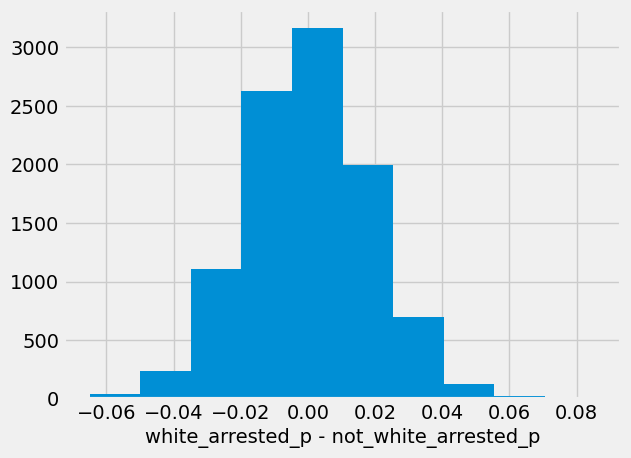

In [406]:
# Code to plot a histogram of p_differences
plt.hist(p_differences)
plt.xlabel("white_arrested_p - not_white_arrested_p")


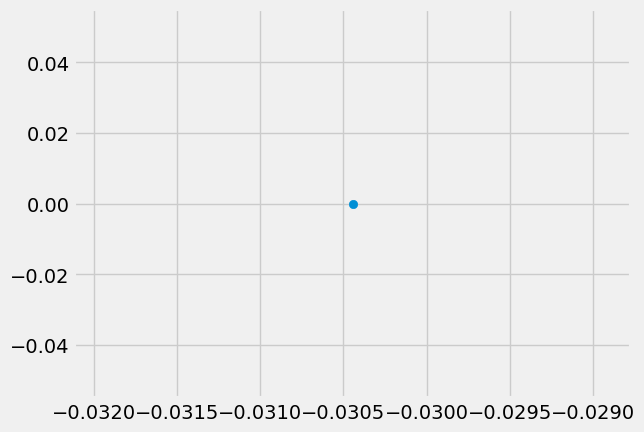

In [412]:
plt.scatter(p_diff, 0);


Make any other cells you would like, to help you answer the question.
plt.scatter(p_diff, 0);

Based on the evidence above, how likely is it that, in the long run, "White
British" people have the same chance of arrest after they are stopped and
searched as do not-White British people?

Assign either 1, 2, 3, 4, or 5 to the name `likely_outcome_same` below.

1. Reasonably likely.
2. Fairly unlikely, but not unlikely enough to be surprising.
3. Unlikely, but we still have some doubt that model is incorrect.
4. Highly unlikely, we have strong evidence the model is incorrect.
5. The observed result is impossible given the model assuming no difference.

In [410]:
#- 3 marks / 100 (total 100 so far)
likely_outcome_same = 2

The next cell checks that your answer above is in the correct format. This
test *does not* check that you answered correctly; only that you assigned a
number successfully in the multiple-choice answer cell.

In [411]:
_ = ok.grade('q_24_outcome_same')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed



## Done.

Congratulations, you're done with the assignment!  Be sure to:

- **run all the tests** (the next cell has a shortcut for that),
- **Save and Checkpoint** from the `File` menu,

**Remember - the tests only test that your answers are compatible with the
right answer.  For example, they may test whether your answer is in the right
format.  They do not test whether your answer is correct**.

In [383]:
# For your convenience, you can run this cell to run all the tests at once!
import os
_ = [ok.grade(q[:-3]) for q in os.listdir("tests") if q.startswith('q')]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------------------------------------------------------------
Test summary
    Passed: 3
    Failed: 0
[ooooooooook] 100.0% passed

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Running tests

---------------